In [55]:
from pathlib import Path
import sys

# Add notebook directory so reactor_parameters can be found
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_nb_dir = next((p for p in _candidates if (p / "reactor_parameters.py").is_file()), None)
if _nb_dir is not None and str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import matplotlib.pyplot as plt

from reactor_parameters import *
# Override: short simulation time
max_simulation_time = 1 * 24.0 * 3600.0

# Iterative cycle to plot different T fractions

In [56]:
T_i = 300

In [57]:
Tf0_cases = [0.5, 0.51, 0.52, 0.53, 0.54, 0.55]
case_linestyles = ["-", "--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1))]
selected_species = ["D", "T", "He4"]
species_colors = {"D": "tab:blue", "T": "tab:orange", "He4": "tab:green"}

### Run setup and solve

In [58]:
case_results = []
for Tf0 in Tf0_cases:
    sp_params = {
        "D": {
            "f_0": 1.0 - Tf0, "tau_p": tau_p_T, "tau_ifc": np.inf, "tau_ofc": np.inf,
            "N_stor_min": 0.0, "Ndot_max": np.inf,
            "N_ofc_0": float(SPECIES_DEFAULTS["D"]["N_ofc_0"]),
            "N_ifc_0": float(SPECIES_DEFAULTS["D"]["N_ifc_0"]),
            "N_stor_0": float(SPECIES_DEFAULTS["D"]["N_stor_0"]),
            "injection_mode": "auto",
            "enable_plasma_channel": True,
        },
        "T": {
            "f_0": Tf0, "tau_p": tau_p_T, "tau_ifc": 4.0 * 3600.0, "tau_ofc": 7200.0,
            "N_stor_min": 0.0, "Ndot_max": np.inf,
            "N_ofc_0": float(SPECIES_DEFAULTS["T"]["N_ofc_0"]),
            "N_ifc_0": float(SPECIES_DEFAULTS["T"]["N_ifc_0"]),
            "N_stor_0": 100.0 / T_mass,
            "injection_mode": "auto",
            "enable_plasma_channel": True,
        },
        "He3": {
            "f_0": 0.0, "tau_p": tau_p_T, "tau_ifc": np.inf, "tau_ofc": np.inf,
            "N_stor_min": 0.0, "Ndot_max": 0.0,
            "N_ofc_0": float(SPECIES_DEFAULTS["He3"]["N_ofc_0"]),
            "N_ifc_0": float(SPECIES_DEFAULTS["He3"]["N_ifc_0"]),
            "N_stor_0": float(SPECIES_DEFAULTS["He3"]["N_stor_0"]),
            "enable_plasma_channel": True,
        },
        "He4": {
            "f_0": 0.0, "tau_p": tau_p_T, "tau_ifc": np.inf, "tau_ofc": np.inf,
            "N_stor_min": 0.0, "Ndot_max": 0.0,
            "N_ofc_0": float(SPECIES_DEFAULTS["He4"]["N_ofc_0"]),
            "N_ifc_0": float(SPECIES_DEFAULTS["He4"]["N_ifc_0"]),
            "N_stor_0": float(SPECIES_DEFAULTS["He4"]["N_stor_0"]),
            "enable_plasma_channel": True,
        },
    }

    inject_from_storage_case = {"D": False, "T": True, "He3": False, "He4": False}
    injection_mode_case = {"D": "auto", "T": "auto", "He3": "off", "He4": "off"}

    species_params = {
        sp: {
            "tau_p": float(sp_params[sp]["tau_p"]),
            "lambda_decay": float(sp_params[sp].get("lambda_decay", SPECIES_DEFAULTS[sp]["lambda_decay"])),
            "tau_ifc": float(sp_params[sp]["tau_ifc"]),
            "tau_ofc": float(sp_params[sp]["tau_ofc"]),
            "N_stor_min": float(sp_params[sp]["N_stor_min"]),
            "Ndot_max": float(sp_params[sp]["Ndot_max"]),
            "inject_from_storage": bool(sp_params[sp].get("inject_from_storage", inject_from_storage_case[sp])),
            "injection_mode": str(sp_params[sp].get("injection_mode", injection_mode_case[sp])),
            "enable_plasma_channel": bool(sp_params[sp]["enable_plasma_channel"]),
        }
        for sp in SPECIES
    }

    initial_conditions = {
        sp: {
            "f_0": float(sp_params[sp]["f_0"]),
            "N_ofc_0": float(sp_params[sp]["N_ofc_0"]),
            "N_ifc_0": float(sp_params[sp]["N_ifc_0"]),
            "N_stor_0": float(sp_params[sp]["N_stor_0"]),
        }
        for sp in SPECIES
    }

    target_conditions = [
        {
            "target_specie": "T",
            "metric": "stor",
            "value": 2.0 * float(initial_conditions["T"]["N_stor_0"]),
        }
    ]

    reactivities_case = compute_reactivities_from_functions(float(T_i))

    injection_mix_weights_case = {
        "D": max(1.0e-12, 1.0 - float(Tf0)),
        "T": max(1.0e-12, float(Tf0)),
    }

    res_case = solve_multispecies_ode_system(
        V_plasma=float(V_plasma),
        T_i=float(T_i),
        n_tot=float(n_tot),
        species_params=species_params,
        initial_conditions=initial_conditions,
        TBR_DT=TBR_DT,
        TBR_DDn=TBR_DD,
        max_simulation_time=float(max_simulation_time),
        vector_length=int(vector_length),
        reactivities=reactivities_case,
        target_conditions=target_conditions,
        injection_mix_weights=injection_mix_weights_case,
    )

    case_results.append({"Tf0": Tf0, "res": res_case, "reactivities": reactivities_case})
    print(f"Tf0={Tf0:.2f}: success={res_case['sol_success']}, t_final={np.asarray(res_case['t'])[-1]/86400:.1f} d")

print(f"\nCompleted {len(case_results)} cases.")

Tf0=0.50: success=False, t_final=1.0 d
Tf0=0.51: success=False, t_final=1.0 d
Tf0=0.52: success=False, t_final=1.0 d
Tf0=0.53: success=False, t_final=1.0 d
Tf0=0.54: success=False, t_final=1.0 d
Tf0=0.55: success=False, t_final=1.0 d

Completed 6 cases.


Final-time metrics by Tf0:
Tf0=0.50: f_D=4.8947e-01, f_T=4.9013e-01, f_He4=1.9596e-02, T_ifc=8.2807e-01 kg, T_ofc=1.7463e-02 kg, T_stor=9.9157e+01 kg, P_total=1.2401e+09 W
Tf0=0.51: f_D=4.7940e-01, f_T=5.0018e-01, f_He4=1.9648e-02, T_ifc=8.4427e-01 kg, T_ofc=1.7430e-02 kg, T_stor=9.9139e+01 kg, P_total=1.2407e+09 W
Tf0=0.52: f_D=4.6934e-01, f_T=5.1023e-01, f_He4=1.9686e-02, T_ifc=8.6045e-01 kg, T_ofc=1.7383e-02 kg, T_stor=9.9121e+01 kg, P_total=1.2405e+09 W
Tf0=0.53: f_D=4.5928e-01, f_T=5.2030e-01, f_He4=1.9711e-02, T_ifc=8.7662e-01 kg, T_ofc=1.7324e-02 kg, T_stor=9.9102e+01 kg, P_total=1.2394e+09 W
Tf0=0.54: f_D=4.4923e-01, f_T=5.3037e-01, f_He4=1.9723e-02, T_ifc=8.9278e-01 kg, T_ofc=1.7250e-02 kg, T_stor=9.9084e+01 kg, P_total=1.2374e+09 W
Tf0=0.55: f_D=4.3918e-01, f_T=5.4045e-01, f_He4=1.9721e-02, T_ifc=9.0892e-01 kg, T_ofc=1.7164e-02 kg, T_stor=9.9066e+01 kg, P_total=1.2347e+09 W


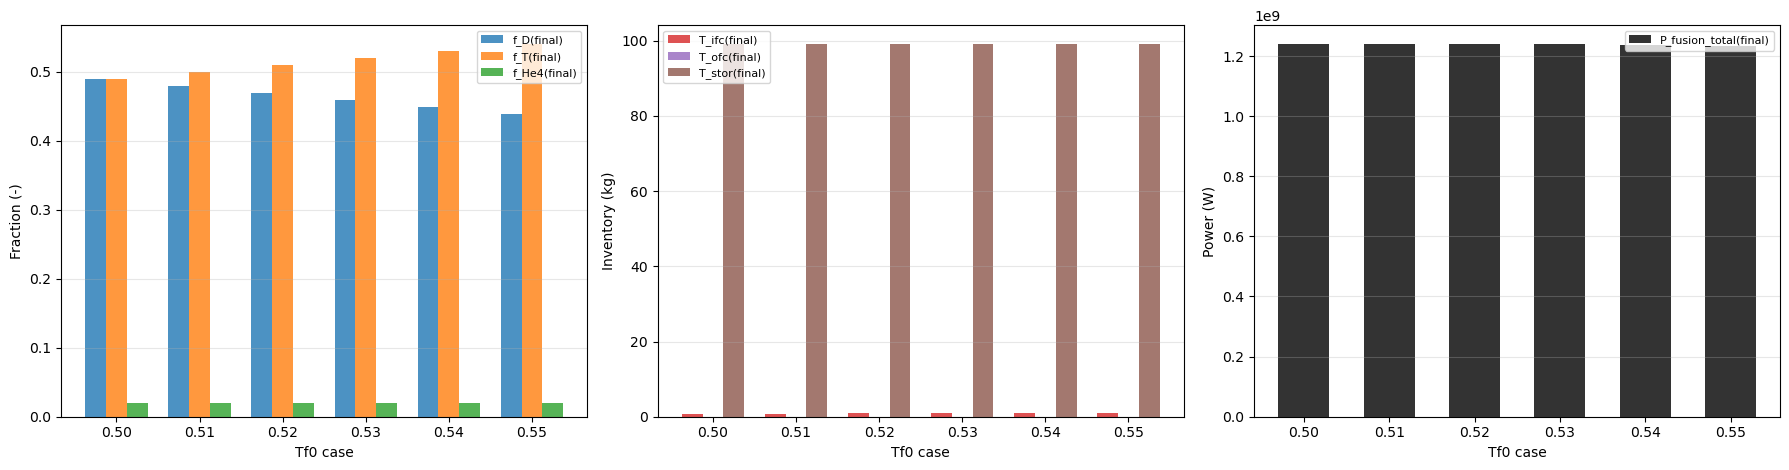

In [59]:
tf0_vals = np.array([float(case['Tf0']) for case in case_results], dtype=float)
order = np.argsort(tf0_vals)
tf0_sorted = tf0_vals[order]
case_labels = [f"{v:.2f}" for v in tf0_sorted]

f_D_final = np.array([float(np.asarray(case['res']['n_D'], dtype=float)[-1] / n_tot) for case in case_results], dtype=float)[order]
f_T_final = np.array([float(np.asarray(case['res']['n_T'], dtype=float)[-1] / n_tot) for case in case_results], dtype=float)[order]
f_He4_final = np.array([float(np.asarray(case['res']['n_He4'], dtype=float)[-1] / n_tot) for case in case_results], dtype=float)[order]

T_ifc_final_kg = np.array([
    float(np.asarray(case['res']['N_ifc_T'], dtype=float)[-1] * species_mass['T'])
    for case in case_results
], dtype=float)[order]
T_ofc_final_kg = np.array([
    float(np.asarray(case['res']['N_ofc_T'], dtype=float)[-1] * species_mass['T'])
    for case in case_results
], dtype=float)[order]
T_stor_final_kg = np.array([
    float(np.asarray(case['res']['N_stor_T'], dtype=float)[-1] * species_mass['T'])
    for case in case_results
], dtype=float)[order]

def _p_total_final(case):
    reactivities = case['reactivities']
    n_D = max(float(np.asarray(case['res'].get('n_D', np.array([0.0])), dtype=float)[-1]), 0.0)
    n_T = max(float(np.asarray(case['res'].get('n_T', np.array([0.0])), dtype=float)[-1]), 0.0)
    n_He3 = max(float(np.asarray(case['res'].get('n_He3', np.array([0.0])), dtype=float)[-1]), 0.0)
    return float(
        V_plasma * (
            0.5 * n_D**2 * float(reactivities['sigmav_DD_n']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_DD_n'])
            + 0.5 * n_D**2 * float(reactivities['sigmav_DD_p']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_DD_p'])
            + n_D * n_T * float(reactivities['sigmav_DT']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_DT'])
            + n_D * n_He3 * float(reactivities['sigmav_DHe3']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_DHe3'])
            + 0.5 * n_T**2 * float(reactivities['sigmav_TT']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_TT'])
            + 0.5 * n_He3**2 * float(reactivities['sigmav_He3He3']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_He3He3'])
            + n_T * n_He3 * float(reactivities['sigmav_THe3_ch1']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_THe3_ch1'])
            + n_T * n_He3 * float(reactivities['sigmav_THe3_ch2']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_THe3_ch2'])
            + n_T * n_He3 * float(reactivities['sigmav_THe3_ch3']) * float(REACTION_ENERGY_BY_CHANNEL['sigmav_THe3_ch3'])
        )
    )

P_fusion_total_final = np.array([_p_total_final(case) for case in case_results], dtype=float)[order]

print('Final-time metrics by Tf0:')
for i, tf0 in enumerate(tf0_sorted):
    print(
        f"Tf0={tf0:.2f}: f_D={f_D_final[i]:.4e}, f_T={f_T_final[i]:.4e}, f_He4={f_He4_final[i]:.4e}, "
        f"T_ifc={T_ifc_final_kg[i]:.4e} kg, T_ofc={T_ofc_final_kg[i]:.4e} kg, T_stor={T_stor_final_kg[i]:.4e} kg, "
        f"P_total={P_fusion_total_final[i]:.4e} W"
    )

x = np.arange(len(tf0_sorted))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

ax = axes[0]
bar_w = 0.25
ax.bar(x - bar_w, f_D_final, width=bar_w, color='tab:blue', alpha=0.8, label='f_D(final)')
ax.bar(x, f_T_final, width=bar_w, color='tab:orange', alpha=0.8, label='f_T(final)')
ax.bar(x + bar_w, f_He4_final, width=bar_w, color='tab:green', alpha=0.8, label='f_He4(final)')
ax.set_xlabel('Tf0 case')
ax.set_ylabel('Fraction (-)')
ax.set_xticks(x)
ax.set_xticklabels(case_labels)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x - bar_w, T_ifc_final_kg, width=bar_w, color='tab:red', alpha=0.8, label='T_ifc(final)')
ax.bar(x, T_ofc_final_kg, width=bar_w, color='tab:purple', alpha=0.8, label='T_ofc(final)')
ax.bar(x + bar_w, T_stor_final_kg, width=bar_w, color='tab:brown', alpha=0.8, label='T_stor(final)')
ax.set_xlabel('Tf0 case')
ax.set_ylabel('Inventory (kg)')
ax.set_xticks(x)
ax.set_xticklabels(case_labels)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

ax = axes[2]
ax.bar(x, P_fusion_total_final, width=0.6, color='k', alpha=0.8, label='P_fusion_total(final)')
ax.set_xlabel('Tf0 case')
ax.set_ylabel('Power (W)')
ax.set_xticks(x)
ax.set_xticklabels(case_labels)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


In [60]:
for case in case_results:
    t_ref = np.asarray(case['res']["t"], dtype=float)
    n_D = np.maximum(np.asarray(case['res'].get("n_D", np.zeros_like(t_ref)), dtype=float), 0.0)
    n_T = np.maximum(np.asarray(case['res'].get("n_T", np.zeros_like(t_ref)), dtype=float), 0.0)
    n_He3 = np.maximum(np.asarray(case['res'].get("n_He3", np.zeros_like(t_ref)), dtype=float), 0.0)

    (
        P_DDn,
        P_DDp,
        P_DT,
        P_DHe3,
        P_TT,
        P_He3He3,
        P_THe3_ch1,
        P_THe3_ch2,
        P_THe3_ch3,
        P_DT_eq,
    ) = compute_fusion_power_profiles_numba(
        n_D,
        n_T,
        n_He3,
        float(n_tot),
        float(V_plasma),
        float(case['reactivities']["sigmav_DD_p"]),
        float(case['reactivities']["sigmav_DD_n"]),
        float(case['reactivities']["sigmav_DT"]),
        float(case['reactivities']["sigmav_DHe3"]),
        float(case['reactivities']["sigmav_TT"]),
        float(case['reactivities']["sigmav_He3He3"]),
        float(case['reactivities']["sigmav_THe3_ch1"]),
        float(case['reactivities']["sigmav_THe3_ch2"]),
        float(case['reactivities']["sigmav_THe3_ch3"]),
    )

    P_fusion_total = P_DDn + P_DDp + P_DT + P_DHe3 + P_TT + P_He3He3 + P_THe3_ch1 + P_THe3_ch2 + P_THe3_ch3
    case["P_DDn"] = np.asarray(P_DDn, dtype=float)
    case["P_DDp"] = np.asarray(P_DDp, dtype=float)
    case["P_DT"] = np.asarray(P_DT, dtype=float)
    case["P_DHe3"] = np.asarray(P_DHe3, dtype=float)
    case["P_TT"] = np.asarray(P_TT, dtype=float)
    case["P_He3He3"] = np.asarray(P_He3He3, dtype=float)
    case["P_THe3_ch1"] = np.asarray(P_THe3_ch1, dtype=float)
    case["P_THe3_ch2"] = np.asarray(P_THe3_ch2, dtype=float)
    case["P_THe3_ch3"] = np.asarray(P_THe3_ch3, dtype=float)
    case["P_DT_eq"] = np.asarray(P_DT_eq, dtype=float)
    case["P_fusion_total"] = np.asarray(P_fusion_total, dtype=float)


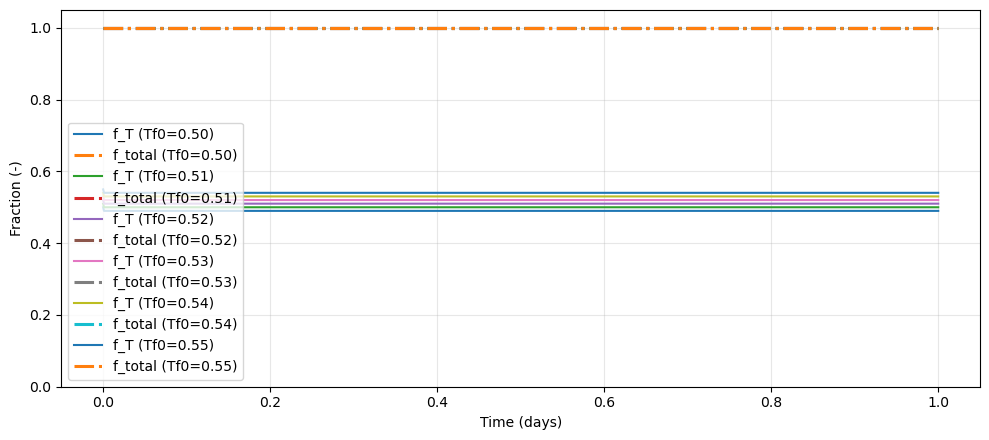

In [61]:
# Fractions overlay
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
for idx_case in order:
    case = case_results[int(idx_case)]
    tf0_case = float(case["Tf0"])
    t_days = np.asarray(case["res"]["t"], dtype=float) / 86400.0
    n_T = np.asarray(case["res"]["n_T"], dtype=float) / n_tot
    total = np.zeros_like(t_days, dtype=float)
    for sp in SPECIES:
        key = f"n_{sp}"
        if key in case["res"]:
            total = total + np.asarray(case["res"][key], dtype=float)
    ax.plot(t_days, n_T, label=f"f_T (Tf0={tf0_case:.2f})")
    ax.plot(t_days, total / n_tot, lw=2.2, ls='-.', label=f"f_total (Tf0={tf0_case:.2f})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Fraction (-)")
ax.set_yscale("linear")
ax.set_ylim(0.0, 1.05   )
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


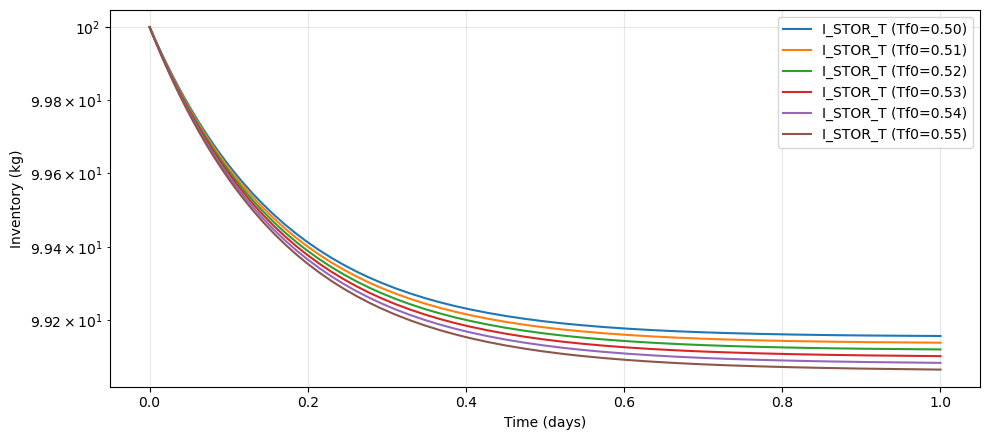

In [62]:
# T storage inventory overlay
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
for idx_case in order:
    case = case_results[int(idx_case)]
    tf0_case = float(case["Tf0"])
    t_days = np.asarray(case["res"]["t"], dtype=float) / 86400.0
    stor_kg = np.asarray(case["res"]["N_stor_T"], dtype=float) * species_mass["T"]
    ax.plot(t_days, stor_kg, label=f"I_STOR_T (Tf0={tf0_case:.2f})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Inventory (kg)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


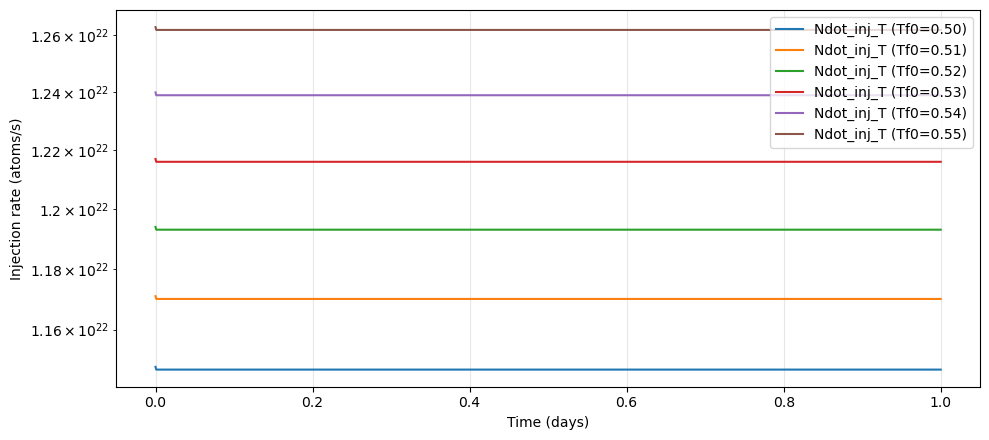

In [63]:
# T injection-rate overlay
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
for idx_case in order:
    case = case_results[int(idx_case)]
    tf0_case = float(case["Tf0"])
    t_days = np.asarray(case["res"]["t"], dtype=float) / 86400.0
    ndot = np.asarray(case["res"]["Ndot_inj_T"], dtype=float)
    ax.plot(t_days, ndot, label=f"Ndot_inj_T (Tf0={tf0_case:.2f})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


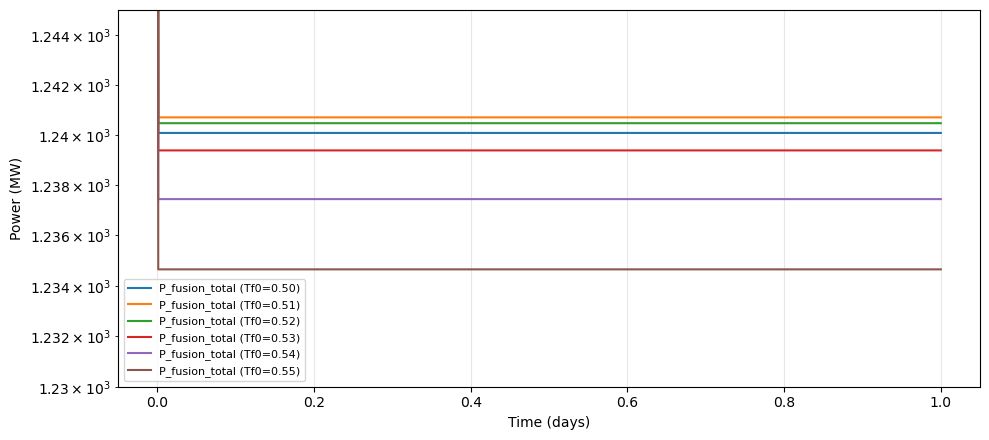

In [64]:
# Fusion-power overlay
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
for idx_case in order:
    case = case_results[int(idx_case)]
    tf0_case = float(case["Tf0"])
    t_days = np.asarray(case["res"]["t"], dtype=float) / 86400.0
    series = np.asarray(case["P_fusion_total"], dtype=float) * 1.0e-6
    series = np.where(series > 0.0, series, np.nan)
    if np.any(np.isfinite(series)):
        ax.plot(t_days, series, label=f"P_fusion_total (Tf0={tf0_case:.2f})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Power (MW)")
ax.set_yscale("log")
ax.set_ylim(1.23e3, 1.245e3)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
